In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from amocatlas import read
from scipy.stats import linregress

import amoc_analysis.correlation_trends as ct


# Data

In [42]:
# Load the datasets
ts_gridded=xr.load_dataset(r"..\data\ts_gridded.nc")
moc_transports=xr.load_dataset(r"..\data\moc_transports.nc")
WH41N=read.wh41n()

Loading 1 Willis & Hobbs 41°N dataset(s):
  0. hobbs_willis_amoc41N_tseries.txt: Transport time series of Ekman volume, Northward geostrophc, Meridional Overturning volume and Meridional Overturning Heat



In [43]:
#Rename variables to be compatible with the script
rename_dict_ts = {
    'time':'TIME',
    'pressure': 'PRESSURE',
    'SG_east': 'PSAL_EAST',
    'SG_east_flag': 'PSAL_EAST_FLAG',
    'SG_mareast': 'PSAL_MAREAST',
    'SG_mareast_flag': 'PSAL_MAREAST_FLAG',
    'SG_marwest': 'PSAL_MARWEST',
    'SG_marwest_flag': 'PSAL_MARWEST_FLAG',
    'SG_wb3': 'PSAL_WB3',
    'SG_west': 'PSAL_WEST',
    'SG_west_flag': 'PSAL_WEST_FLAG',
    'TG_east': 'TEMP_EAST',
    'TG_east_flag': 'TEMP_EAST_FLAG',
    'TG_mareast': 'TEMP_MAREAST',
    'TG_mareast_flag': 'TEMP_MAREAST_FLAG',
    'TG_marwest': 'TEMP_MARWEST',
    'TG_marwest_flag': 'TEMP_MARWEST_FLAG',
    'TG_wb3': 'TEMP_WB3',
    'TG_west': 'TEMP_WEST',
    'TG_west_flag': 'TEMP_WEST_FLAG',
}

rename_dict_moc = {
    'time':'TIME',
    'moc_mar_hc10': 'MOC',
    't_therm10': 'TRANS_0_800',
    't_ud10': 'TRANS_1100_3000',
    't_ld10': 'TRANS_3000_5000',
    't_aiw10': 'TRANS_800_1100',
    't_ek10': 'TRANS_EKMAN',
    't_gs10': 'TRANS_FC',
    't_umo10': 'TRANS_UMO',
    't_bw10': 'TRANS_below_5000',
}

while True:
    try:
        ts_gridded = ts_gridded.rename(rename_dict_ts)
        print("Rename complete")
        break
    except Exception as e:
        print(f"Rename failed: {e}\nCheck if ts_gridded already has the right variable names.")
        break

while True:
    try:
        moc_transports = moc_transports.rename(rename_dict_moc)
        print("Rename complete")
        break
    except Exception as e:
        print(f"Rename failed: {e}\nCheck if moc_transports already has the right variable names.")
        break

Rename complete
Rename complete


# Part 1

In [5]:
# Calculate interior geostrophic transport
geo_transport=ct.geostrophy.interior_geostrophic_transport(ts_gridded)

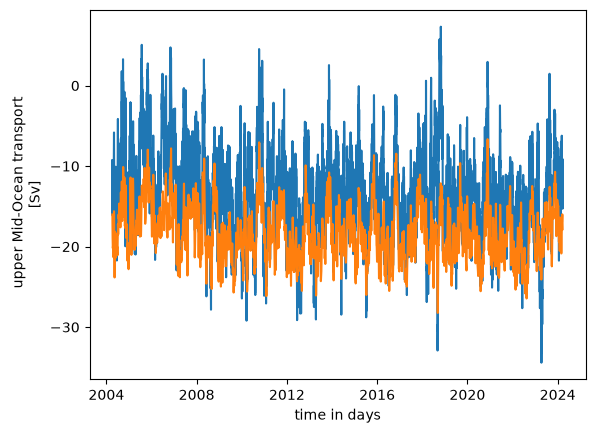

In [6]:
geo_transport.plot()
moc_transports["TRANS_UMO"].plot()

### Correlation

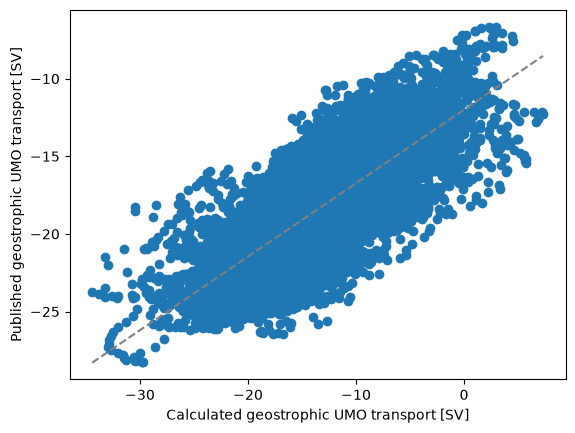

In [7]:
x = np.asarray(geo_transport)
y = np.asarray(moc_transports["TRANS_UMO"])

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

reg = linregress(x_clean, y_clean)

x_sort = np.sort(x_clean)
plt.scatter(x_clean, y_clean)
plt.plot(x_sort, reg.slope * x_sort + reg.intercept, c="grey", ls="--")
plt.xlabel("Calculated geostrophic UMO transport [SV]")
plt.ylabel("Published geostrophic UMO transport [SV]")
plt.show()

# Part 2

## Remove the seasonal cycle

In [8]:
umo=moc_transports.TRANS_UMO
geo_deseasoned=ct.seasonal.remove_seasonal_cycle(geo_transport)
umo_deseasoned=ct.seasonal.remove_seasonal_cycle(umo)

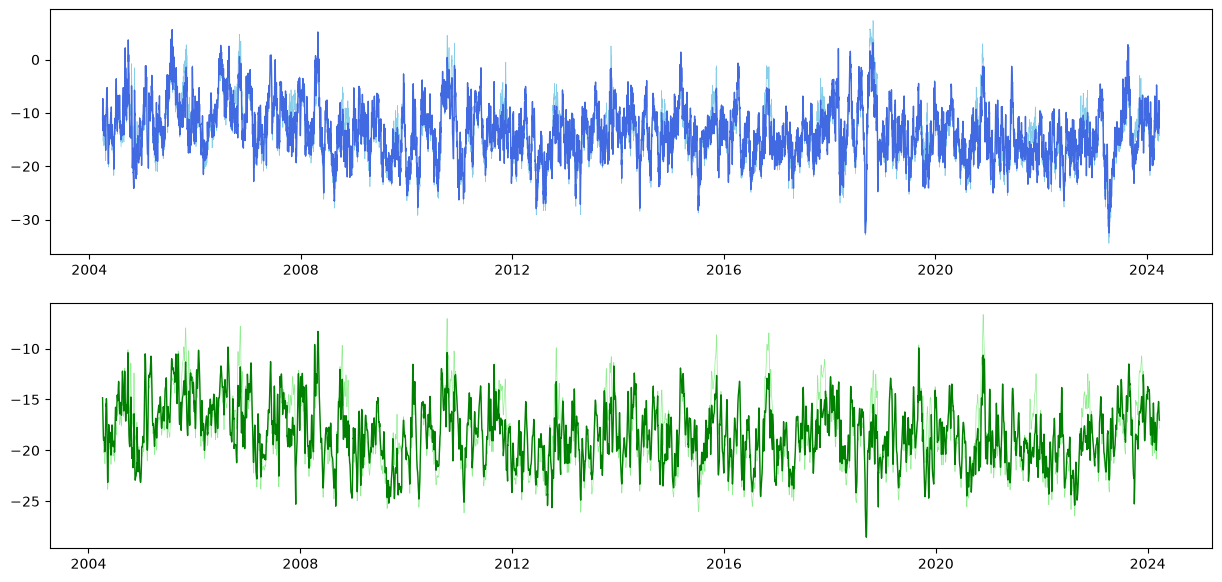

In [9]:
fig,ax=plt.subplots(2,1,figsize=(15,7))
ax[0].plot(geo_transport.TIME,geo_transport,lw=0.5,c="skyblue")
ax[0].plot(geo_deseasoned.TIME,geo_deseasoned,lw=1,c="royalblue")
ax[1].plot(umo.TIME,umo,lw=0.5,c="lightgreen")
ax[1].plot(umo_deseasoned.TIME,umo_deseasoned,lw=1,c="green")

## Autocorrelation

In [10]:
corr_geo=ct.correlation.autocorr(geo_deseasoned)
corr_umo=ct.correlation.autocorr(umo_deseasoned)

tau_geo=ct.correlation.integral_timescale(geo_deseasoned,2)
tau_umo=ct.correlation.integral_timescale(umo_deseasoned,2)

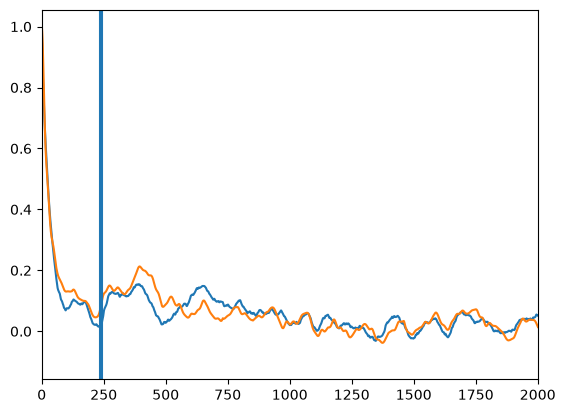

In [11]:
plt.plot(corr_geo)
plt.plot(corr_umo)
plt.xlim(0,2000)
plt.axvline(tau_geo)
plt.axvline(tau_umo)

In [12]:
def time_to_years(time_da):
    """Convert an xarray datetime64 TIME coordinate to float years since start."""
    t = time_da.values.astype("datetime64[ns]")
    t0 = t[0]
    days = (t - t0) / np.timedelta64(1, "D")
    return days / 365.25  # float years since start

t_geo = time_to_years(geo_deseasoned.TIME)
t_umo = time_to_years(umo_deseasoned.TIME)

trend_geo=ct.trends.trend_with_significance(t_geo,geo_deseasoned,2/365)
trend_umo=ct.trends.trend_with_significance(t_umo,umo_deseasoned,2/365)

trend_with_significance: dropping 20.0/14599 NaN samples


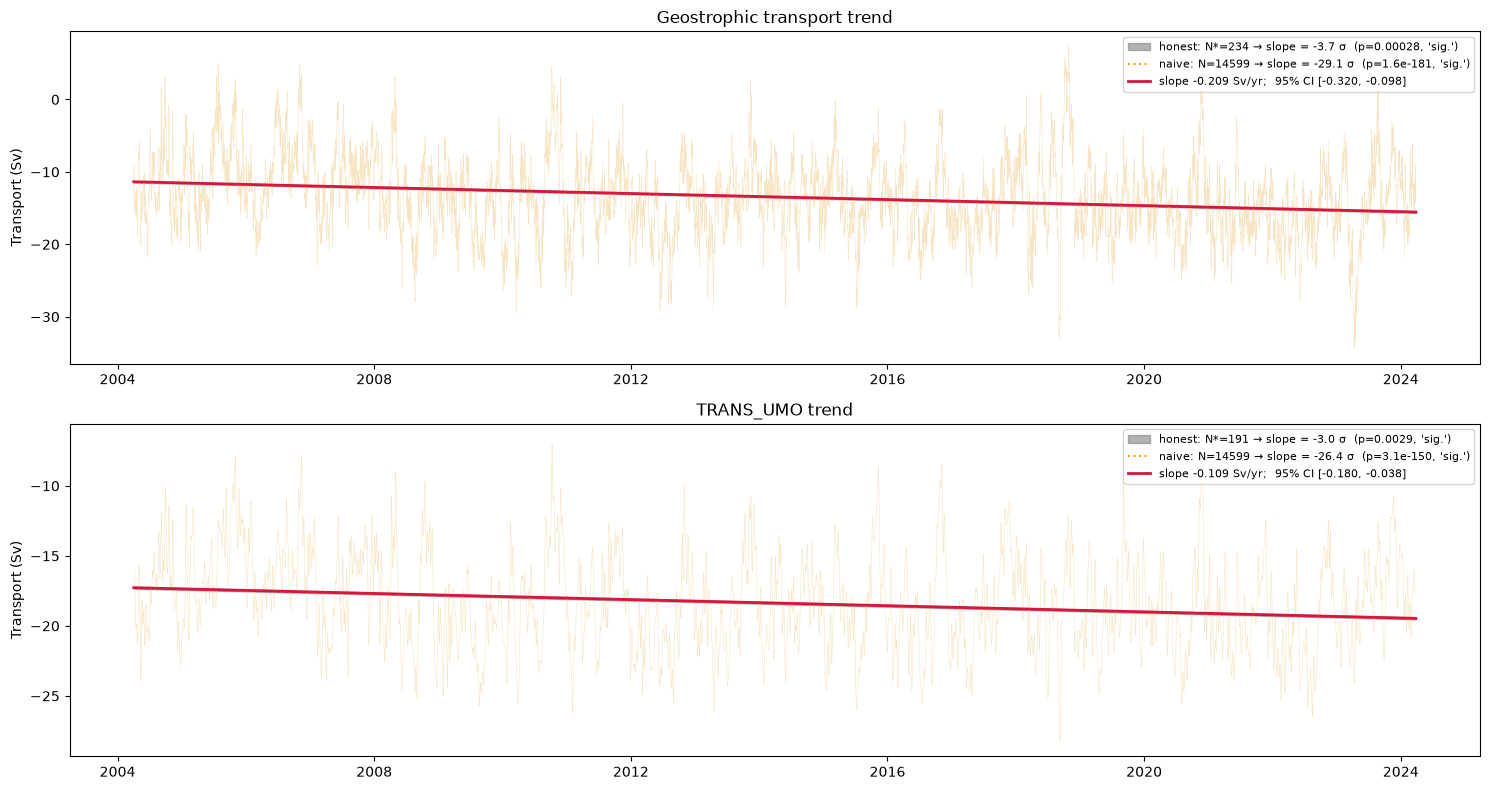

In [13]:
from amoc_analysis import plotting

fig, ax = plt.subplots(2, 1, figsize=(15, 8))

plotting.plot_trend_with_sigma(ax[0], t_geo, geo_deseasoned.TIME, geo_transport, geo_deseasoned,
                       trend_geo, N_raw=len(geo_transport), title="Geostrophic transport trend")

plotting.plot_trend_with_sigma(ax[1], t_umo, umo_deseasoned.TIME, umo, umo_deseasoned,
                       trend_umo, N_raw=len(umo), title="TRANS_UMO trend")

plt.tight_layout()
plt.show()

## Cross correlation

In [14]:
# Pick two series:
# WH41N   sampling:monthly     filter: 3-month low-pass (boxcar)
# RAPID   sampling:12h         filter: 10-day low-pass

rapid=moc_transports.MOC
wh41n=WH41N.MOC

#Filter the RAPID data
s = pd.Series(rapid.values, index=pd.to_datetime(moc_transports.TIME.values), dtype="float64")
rapid_3m= s.rolling("90D", center=True, min_periods=1).mean()

#Put Rapid on the same grid as WH41N
rapid_monthly = rapid_3m.resample("1MS").mean()

wh41n_series = pd.Series(wh41n.values, index=pd.to_datetime(WH41N.TIME.values), dtype="float64")

rapid_monthly.index = rapid_monthly.index.to_period("M").to_timestamp()
wh41n_series.index = wh41n_series.index.to_period("M").to_timestamp()


combined = pd.concat({"wh41n": wh41n_series, "rapid": rapid_monthly}, axis=1, join="inner")

wh41n_aligned = combined["wh41n"].to_xarray()
rapid_aligned = combined["rapid"].to_xarray()



In [ ]:
#Remove seasonal cycle
wh41n_deseasoned=ct.seasonal.remove_seasonal_cycle(wh41n_aligned,group="index.month")
rapid_deseasoned=ct.seasonal.remove_seasonal_cycle(rapid_aligned,group="index.month")

#Calculkate cross correlation
lags_raw,r_raw=ct.correlation.cross_correlation(wh41n_aligned,rapid_aligned)
lags,r=ct.correlation.cross_correlation(wh41n_deseasoned,rapid_deseasoned)


Peak lag: -2 months


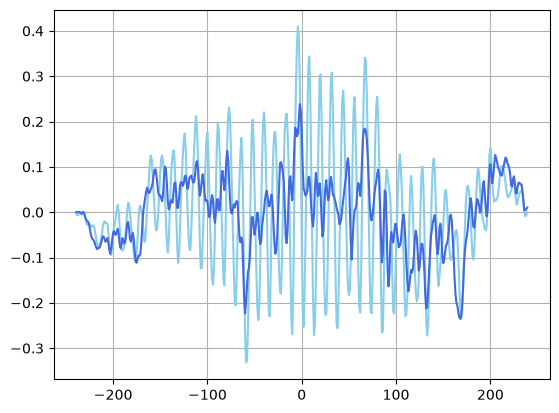

In [33]:
plt.plot(lags_raw,r_raw,c="skyblue")
plt.plot(lags,r,c="royalblue")
plt.grid()

peak_lag = lags[np.argmax(r)]
print(f"Peak lag: {peak_lag} months")


# Part 3

In [44]:
# Sensitivity of integration depth in geostrophic transport
geo_700=ct.geostrophy.interior_geostrophic_transport(ts_gridded,z_max=700)
geo_1000=ct.geostrophy.interior_geostrophic_transport(ts_gridded,z_max=1000)
geo_1100=ct.geostrophy.interior_geostrophic_transport(ts_gridded,z_max=1100)
geo_1300=ct.geostrophy.interior_geostrophic_transport(ts_gridded,z_max=1300)


In [ ]:
#only show differences to published product
geo_700_sub=(geo_700-geo_1100)
geo_1000_sub=(geo_1000-geo_1100)
geo_1100_sub=(geo_1100-geo_1100)
geo_1300_sub=(geo_1300-geo_1100)

umo=moc_transports.TRANS_UMO

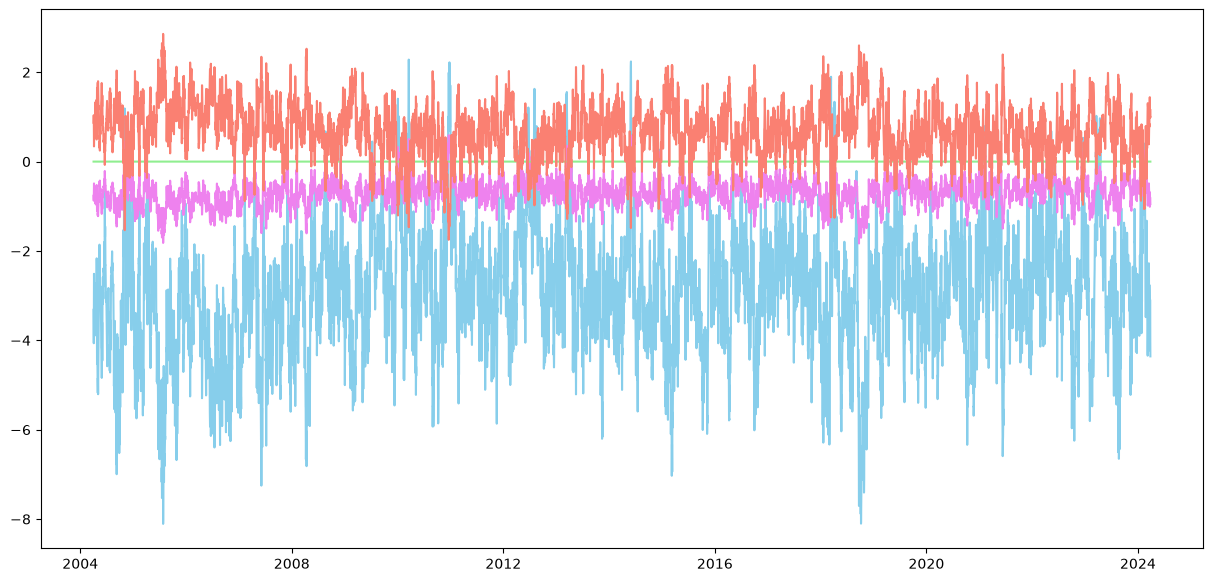

In [83]:
plt.figure(figsize=(15,7))
plt.plot(geo_700.TIME,geo_700_sub,c="skyblue")
plt.plot(geo_1000.TIME,geo_1000_sub,c="violet")
plt.plot(geo_1100.TIME,geo_1100_sub,c="lightgreen")
plt.plot(geo_1300.TIME,geo_1300_sub,c="salmon")
#plt.plot(umo.TIME,umo-geo_1100,c="grey",ls="--")

In [86]:
results = []
for name, series in [("700 m", geo_700), ("1000 m", geo_1000), ("1100 m", geo_1100), ("1300 m", geo_1300)]:
    corr_with_1100 = np.corrcoef(series.values, geo_1100.values)[0, 1] #if name != "1100 m" else 1.0
    results.append({
        "Integration depth": name,
        "Mean (Sv)": series.mean().item(),
        "Std (Sv)": series.std().item(),
        "Correlation with 1100m": corr_with_1100,
    })

pd.DataFrame(results)

,Integration depth,Mean (Sv),Std (Sv),Correlation with 1100m
0,700 m,-16.375105,4.401429,0.984810
1,1000 m,-14.107682,5.290731,0.999062
2,1100 m,-13.455614,5.501137,1.000000
3,1300 m,-12.775780,5.874200,0.996607
